# **Decision Tree - Prediksi Lanjut Studi Mahasiswa**
##### Nama  : Maryam Hasnaa' Syamila
##### NIM   : 0110222067
##### Kelas : ML-PAGI

### **Import Library**

In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

###**Data Understanding - Load Dataset**

In [ ]:
# Sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

# load dataset
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/datasets/college.csv', sep=',')
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


### **Data Preparation - Data Preprocessing**


In [ ]:
# melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


In [ ]:
# cek missing value
df.isnull().sum()

,0
StudentID,0
Gender,0
Parent_income,0
IQ,0
Encourage,0
Plan,0


In [ ]:
# cek duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# Cek distribusi kelas target
df['Plan'].value_counts()

,count
Plan,
not plan,5404
plan,2596


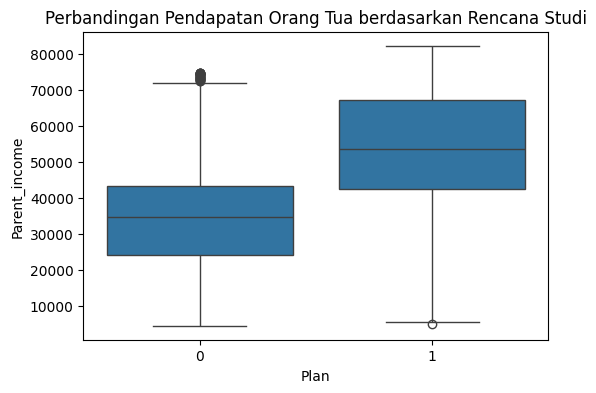

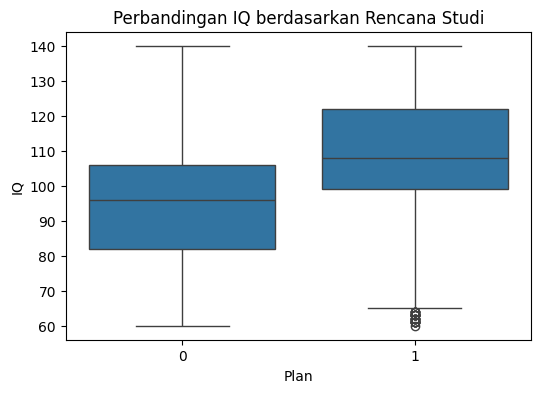

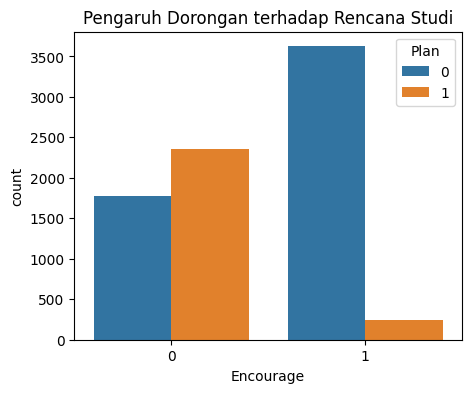

In [ ]:
# Pendapatan orang tua vs Plan
plt.figure(figsize=(6,4))
sns.boxplot(x='Plan', y='Parent_income', data=df)
plt.title("Perbandingan Pendapatan Orang Tua berdasarkan Rencana Studi")
plt.show()

# IQ vs Plan
plt.figure(figsize=(6,4))
sns.boxplot(x='Plan', y='IQ', data=df)
plt.title("Perbandingan IQ berdasarkan Rencana Studi")
plt.show()

# Encourage vs Plan
plt.figure(figsize=(5,4))
sns.countplot(x='Encourage', hue='Plan', data=df)
plt.title("Pengaruh Dorongan terhadap Rencana Studi")
plt.show()

In [ ]:
# Hapus kolom StudentID karena bukan fitur prediktif
df = df.drop(columns=['StudentID'])

# Encode kategori ke numerik
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Pisahkan fitur dan target
X = df.drop(columns=['Plan'])
y = df['Plan']

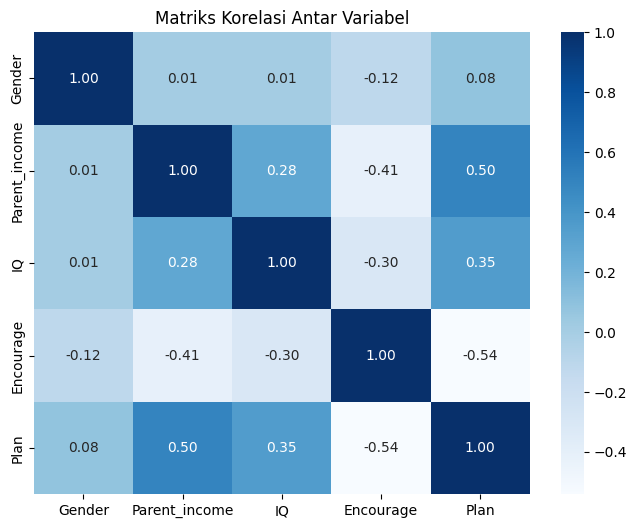

In [ ]:
# Hitung korelasi
corr = df.corr()

# Visualisasi matriks korelasi
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Matriks Korelasi Antar Variabel")
plt.show()

In [ ]:
# Split data untuk training dan testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Modelling - Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Buat model pohon keputusan
dt = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### **Evaluasi Model**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = dt.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi Model: 0.81875

Confusion Matrix:
 [[982  99]
 [191 328]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1081
           1       0.77      0.63      0.69       519

    accuracy                           0.82      1600
   macro avg       0.80      0.77      0.78      1600
weighted avg       0.81      0.82      0.81      1600



### **Visualisasi Model**

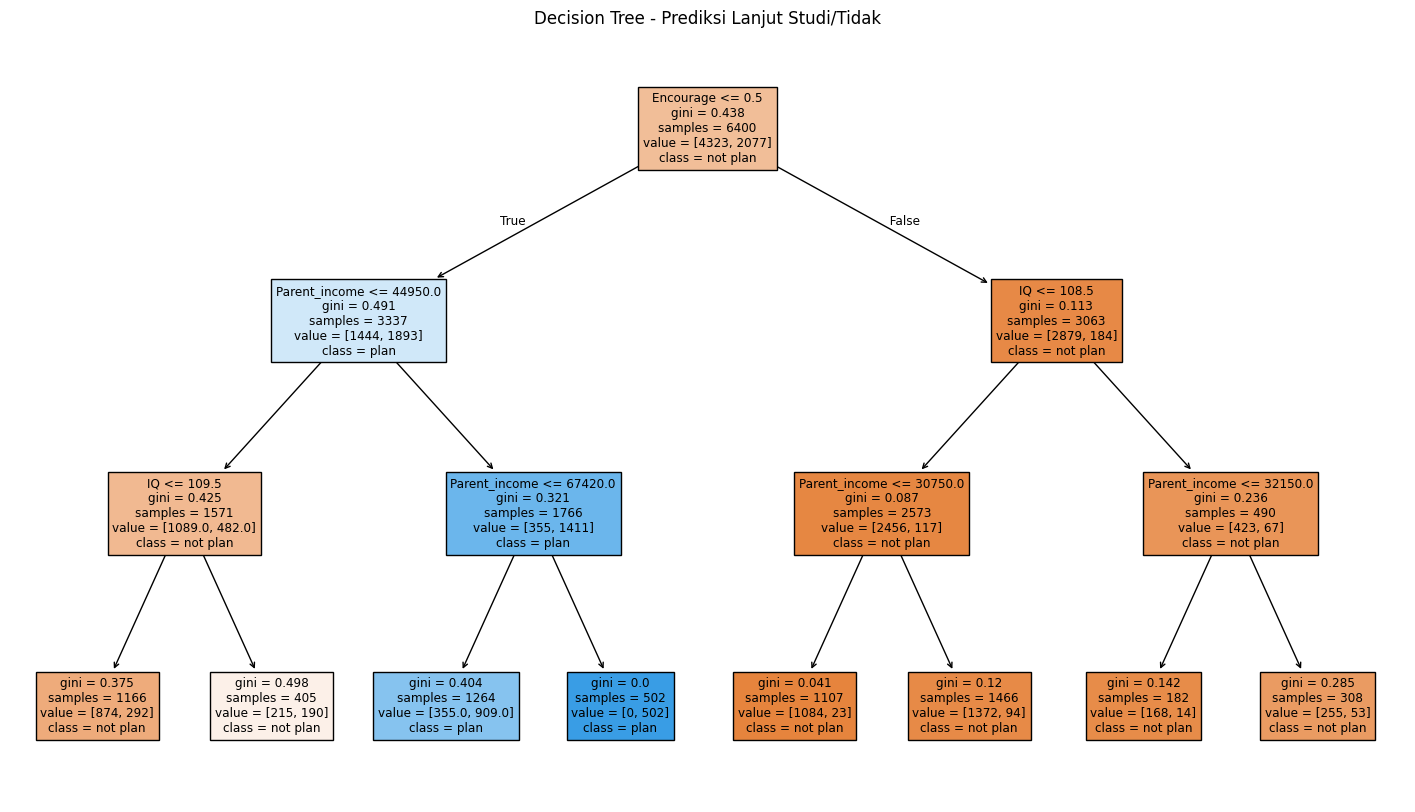

In [ ]:
# visualisasi model
from sklearn import tree
plt.figure(figsize=(18,10))
tree.plot_tree(dt, feature_names=X.columns, class_names=['not plan', 'plan'], filled=True)
plt.title("Decision Tree - Prediksi Lanjut Studi/Tidak")
plt.show()

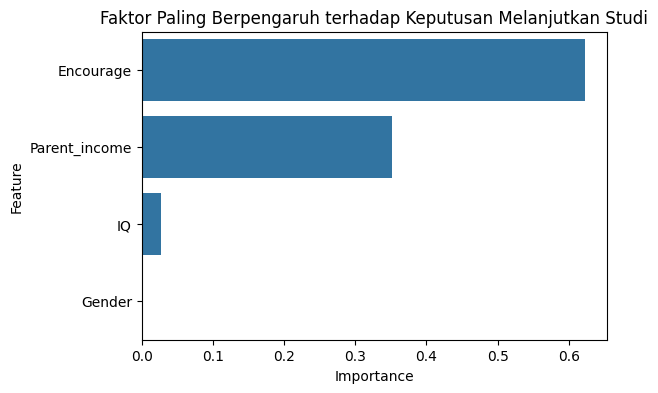

,Feature,Importance
3,Encourage,0.621928
1,Parent_income,0.351117
2,IQ,0.026954
0,Gender,0.000000


In [ ]:
# melihat pengaruh tiap variabel
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Faktor Paling Berpengaruh terhadap Keputusan Melanjutkan Studi")
plt.show()

importance

In [ ]:
import joblib
# Simpan model terbaik ke file .pkl
joblib.dump(best_dt, "decision_tree_college.pkl")

print("✅ Model berhasil disimpan sebagai 'decision_tree_college.pkl'")

✅ Model berhasil disimpan sebagai 'decision_tree_college.pkl'


### **Uji Coba Model**

In [ ]:
import pandas as pd
import joblib

# Muat model yang sudah disimpan
loaded_model = joblib.load("decision_tree_college.pkl")

print("=== Prediksi Keputusan Lanjut Studi ===")
print("Masukkan data berikut:")

# Ambil input pengguna
gender = input("Gender (male/female): ").strip().lower()

# Bersihkan input pendapatan agar aman (hapus koma dan titik ribuan)
income_str = input("Pendapatan orang tua per bulan (Rp): ").strip()
income_str = income_str.replace(",", "").replace(".", "")
parent_income = float(income_str)

iq = float(input("IQ siswa: "))
encourage = input("Dapat dorongan/encouragement? (yes/no): ").strip().lower()

# Ubah input ke format numerik seperti model saat training
gender_enc = 1 if gender == "male" else 0
encourage_enc = 1 if encourage in ["yes", "ya", "encourage"] else 0

# Buat DataFrame input
data_input = pd.DataFrame({
    'Gender': [gender_enc],
    'Parent_income': [parent_income],
    'IQ': [iq],
    'Encourage': [encourage_enc]
})

# Lakukan prediksi
pred = loaded_model.predict(data_input)[0]

# Tampilkan hasil
hasil = "Plan (lanjut studi)" if pred == 1 else "Not Plan (tidak lanjut studi)"
print("\n🎓 Hasil Prediksi:", hasil)

=== Prediksi Keputusan Lanjut Studi ===
Masukkan data berikut:
Gender (male/female): male
Pendapatan orang tua per bulan (Rp): 500.000.000
IQ siswa: 120
Dapat dorongan/encouragement? (yes/no): yes

🎓 Hasil Prediksi: Not Plan (tidak lanjut studi)


### **Hyperparamater Tuning (max_depth terbaik)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

scores = {}

# Loop untuk berbagai nilai max_depth
for d in range(2, nine := 9):
    # Gunakan class_weight='balanced' agar memperhatikan distribusi kelas
    m = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    scores[d] = acc

# Tampilkan hasil
print("Skor akurasi per max_depth:")
for depth, acc in scores.items():
    print(f"max_depth={depth} -> Acc={round(acc*100,2)}%")

# Cari nilai max_depth terbaik
best_d = max(scores, key=scores.get)
print("\n🌟 Best max_depth:", best_d, "| Accuracy:", round(scores[best_d]*100,2), "%")

Skor akurasi per max_depth:
max_depth=2 -> Acc=81.88%
max_depth=3 -> Acc=81.88%
max_depth=4 -> Acc=81.88%
max_depth=5 -> Acc=80.81%
max_depth=6 -> Acc=81.94%
max_depth=7 -> Acc=81.38%
max_depth=8 -> Acc=80.31%

🌟 Best max_depth: 6 | Accuracy: 81.94 %


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.title("Akurasi Model vs max_depth (Balanced Decision Tree)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy (Test Data)")
plt.grid(True)
plt.show()

In [ ]:
# Latih ulang dengan best_d
best_dt = DecisionTreeClassifier(max_depth=best_d, random_state=42, class_weight='balanced')
best_dt.fit(X_train, y_train)

y_pred_best = best_dt.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Akurasi model terbaik:", round(accuracy_score(y_test, y_pred_best)*100,2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Akurasi model terbaik: 81.94 %

Confusion Matrix:
 [[919 162]
 [127 392]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1081
           1       0.71      0.76      0.73       519

    accuracy                           0.82      1600
   macro avg       0.79      0.80      0.80      1600
weighted avg       0.82      0.82      0.82      1600



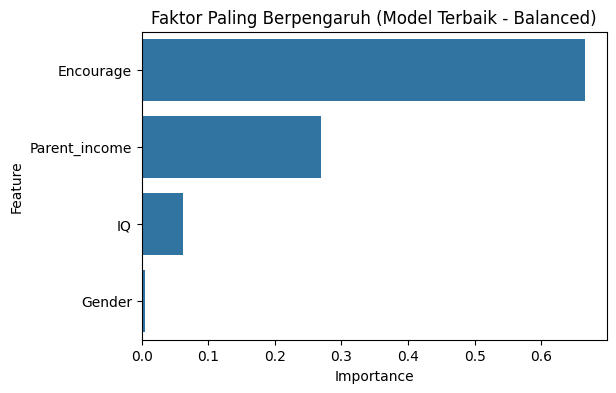

,Feature,Importance
3,Encourage,0.664797
1,Parent_income,0.268906
2,IQ,0.061645
0,Gender,0.004652


In [ ]:
import pandas as pd
import seaborn as sns

importance_best = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=importance_best)
plt.title("Faktor Paling Berpengaruh (Model Terbaik - Balanced)")
plt.show()

importance_best


In [ ]:
import joblib

joblib.dump(best_dt, "decision_tree_college.pkl")
print("✅ Model terbaik disimpan sebagai 'decision_tree_college.pkl'")


✅ Model terbaik disimpan sebagai 'decision_tree_college.pkl'


In [ ]:
import pandas as pd
import joblib

# --- Ambil model terbaik: gunakan best_dt kalau ada, kalau tidak load dari file ---
try:
    best_model = best_dt
    print("Menggunakan model 'best_dt' dari session.")
except NameError:
    try:
        best_model = joblib.load("decision_tree_college.pkl")
        print("Model dimuat dari 'decision_tree_college.pkl'.")
    except Exception as e:
        raise RuntimeError(
            "Model terbaik tidak ditemukan di memory atau file 'decision_tree_college.pkl'. "
            "Pastikan Anda telah melakukan training/tuning dan menyimpan model."
        ) from e

# Pastikan urutan fitur yang dipakai model (sesuaikan kalau training Anda pakai urutan berbeda)
FEATURES = ['Gender', 'Parent_income', 'IQ', 'Encourage']

def parse_income(inp: str) -> float:
    """Bersihkan string pendapatan lalu ubah jadi float.
       Menerima format: 5500000, 5,500,000, 5.500.000, Rp5.500.000, dll."""
    s = str(inp).strip()
    # hapus currency symbol, spasi, dan tanda ribuan
    for token in ['Rp', 'rp', 'IDR', '$', ' ']:
        s = s.replace(token, '')
    s = s.replace(',', '').replace('.', '')
    if s == '':
        raise ValueError("Pendapatan kosong setelah pembersihan.")
    return float(s)

def gender_enc_fn(inp: str) -> int:
    """male -> 1, selainnya -> 0 (sesuai encoding sebelumnya)"""
    v = str(inp).strip().lower()
    return 1 if v in ['male', 'm', 'laki-laki', 'laki'] else 0

def encourage_enc_fn(inp: str) -> int:
    """yes/ya/encourage -> 1, selainnya -> 0"""
    v = str(inp).strip().lower()
    return 1 if v in ['yes', 'y', 'ya', 'encourage', 'true', '1'] else 0

# --- Interaktif input pengguna ---
print("\n=== Prediksi Keputusan Lanjut Studi ===")
print("Masukkan data berikut:")
print("Catatan: tulis pendapatan tanpa simbol mata uang atau spasi; format diterima: 5500000, 5,500,000, 5.500.000, Rp5.500.000")

try:
    gender_in = input("Gender (male/female): ").strip()
    income_in = input("Pendapatan orang tua per bulan (contoh: 5,500,000 atau 5500000): ").strip()
    iq_in = input("IQ siswa (misal 100): ").strip()
    encourage_in = input("Dapat dorongan/encouragement? (yes/no): ").strip()

    # Parsing & validasi
    parent_income = parse_income(income_in)
    iq = float(iq_in)
    gender_enc = gender_enc_fn(gender_in)
    encourage_enc = encourage_enc_fn(encourage_in)

except Exception as e:
    print("Terjadi kesalahan pada input:", e)
    raise

# Susun DataFrame sesuai urutan fitur
data_input = pd.DataFrame([{
    'Gender': gender_enc,
    'Parent_income': parent_income,
    'IQ': iq,
    'Encourage': encourage_enc
}])[FEATURES]

# Prediksi & probabilitas
pred = best_model.predict(data_input)[0]
proba = None
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(data_input)[0]

label_map = {1: "Plan (lanjut studi)", 0: "Not Plan (tidak lanjut studi)"}

print("\n--- Input yang diberikan ---")
print(data_input.to_string(index=False))

print("\n🎯 Hasil Prediksi:", label_map.get(pred, pred))
if proba is not None:
    classes = best_model.classes_
    proba_dict = {int(classes[i]): round(100*proba[i], 2) for i in range(len(classes))}
    print("🔎 Probabilitas per kelas:", proba_dict)

# Optional: tampilkan potongan aturan pohon agar tahu 'mengapa' model memutuskan demikian
try:
    from sklearn.tree import export_text
    if hasattr(best_model, 'tree_'):
        print("\n--- Ringkasan aturan pohon (beberapa baris) ---")
        rules = export_text(best_model, feature_names=FEATURES)
        for i, line in enumerate(rules.splitlines()):
            if i >= 30:
                print("... (aturan dipendekkan)")
                break
            print(line)
except Exception:
    pass

Menggunakan model 'best_dt' dari session.

=== Prediksi Keputusan Lanjut Studi ===
Masukkan data berikut:
Catatan: tulis pendapatan tanpa simbol mata uang atau spasi; format diterima: 5500000, 5,500,000, 5.500.000, Rp5.500.000
Gender (male/female): female
Pendapatan orang tua per bulan (contoh: 5,500,000 atau 5500000): 50000
IQ siswa (misal 100): 110
Dapat dorongan/encouragement? (yes/no): no

--- Input yang diberikan ---
 Gender  Parent_income    IQ  Encourage
      0        50000.0 110.0          0

🎯 Hasil Prediksi: Plan (lanjut studi)
🔎 Probabilitas per kelas: {0: np.float64(13.64), 1: np.float64(86.36)}

--- Ringkasan aturan pohon (beberapa baris) ---
|--- Encourage <= 0.50
|   |--- Parent_income <= 44950.00
|   |   |--- IQ <= 109.50
|   |   |   |--- Parent_income <= 33070.00
|   |   |   |   |--- Parent_income <= 28310.00
|   |   |   |   |   |--- IQ <= 95.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- IQ >  95.50
|   |   |   |   |   |   |--- class: 0
|   |   |  